In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/image-dataset/train_image/train_image/22735.jpg
/kaggle/input/image-dataset/train_image/train_image/20513.jpg
/kaggle/input/image-dataset/train_image/train_image/13288.jpg
/kaggle/input/image-dataset/train_image/train_image/6234.jpg
/kaggle/input/image-dataset/train_image/train_image/24819.jpg
/kaggle/input/image-dataset/train_image/train_image/6241.jpg
/kaggle/input/image-dataset/train_image/train_image/20529.jpg
/kaggle/input/image-dataset/train_image/train_image/10304.jpg
/kaggle/input/image-dataset/train_image/train_image/623.jpg
/kaggle/input/image-dataset/train_image/train_image/2193.jpg
/kaggle/input/image-dataset/train_image/train_image/14143.jpg
/kaggle/input/image-dataset/train_image/train_image/11925.jpg
/kaggle/input/image-dataset/train_image/train_image/3750.jpg
/kaggle/input/image-dataset/train_image/train_image/17338.jpg
/kaggle/input/image-dataset/train_image/train_image/7737.jpg
/kaggle/input/image-dataset/train_image/train_image/2081.jpg
/kaggle/input/im

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.preprocessing import MultiLabelBinarizer
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, roc_auc_score
import seaborn as sns

from tensorflow.keras.layers import (Input, Embedding, Bidirectional, LSTM, Conv1D, GlobalMaxPooling1D, BatchNormalization, Concatenate, Dense, Dropout)
from tensorflow.keras.models import Model


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [5]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))


Num GPUs Available:  2


In [6]:
train_df = pd.read_csv('/kaggle/input/text-dataset/train_split.csv')
val_df = pd.read_csv('/kaggle/input/text-dataset/val_split.csv')
test_df = pd.read_csv('/kaggle/input/text-dataset/test_split.csv')

train_img_dir = '/kaggle/input/image-dataset/train_image/train_image'
val_img_dir = '/kaggle/input/image-dataset/val_image/val_image'
test_img_dir = '/kaggle/input/image-dataset/test_image/test_image'


In [7]:
test_df.head()

,ImageID,Labels,Caption,Labels_list
0,18603.jpg,3,The back side of a vehicle packed with bags.,[3]
1,14898.jpg,17,A bed in a bedroom next to a table with a lamp.,[17]
2,13495.jpg,3 15,A group of people are sitting on a bench outside.,"[3, 15]"
3,4395.jpg,7,A train is being boarded by passengers by a pl...,[7]
4,15857.jpg,3 6,A city bus has it's lights on while driving on...,"[3, 6]"


In [8]:
glove_file = '/kaggle/input/glove/glove.6B.300d.txt'

In [9]:

# Fonction pour convertir les labels string en liste de labels
def parse_labels(label_str):
    # Supposons que vos labels sont stockés sous forme de "[3,4]" ou "[5,7]"
    # Nous devons les convertir en liste d'entiers
    if isinstance(label_str, str):
        # Supprimer les crochets et divisez par virgule
        labels = label_str.strip('[]').split(',')
        # Convertir en entiers et retourner sous forme de liste
        return [int(label) for label in labels if label.strip()]
    return []

# Appliquer la fonction de parsing aux colonnes de labels
train_df['Labels_list'] = train_df['Labels_list'].apply(parse_labels)
val_df['Labels_list'] = val_df['Labels_list'].apply(parse_labels)
test_df['Labels_list'] = test_df['Labels_list'].apply(parse_labels)

Classes: [ 2  3  4  5  6  7  8  9 10 11 13 14 15 16 17 18 19]
Nombre de classes: 17
X_train shape: (11146, 224, 224, 3)
y_train shape: (11146, 17)
X_val shape: (2388, 224, 224, 3)
y_val shape: (2388, 17)


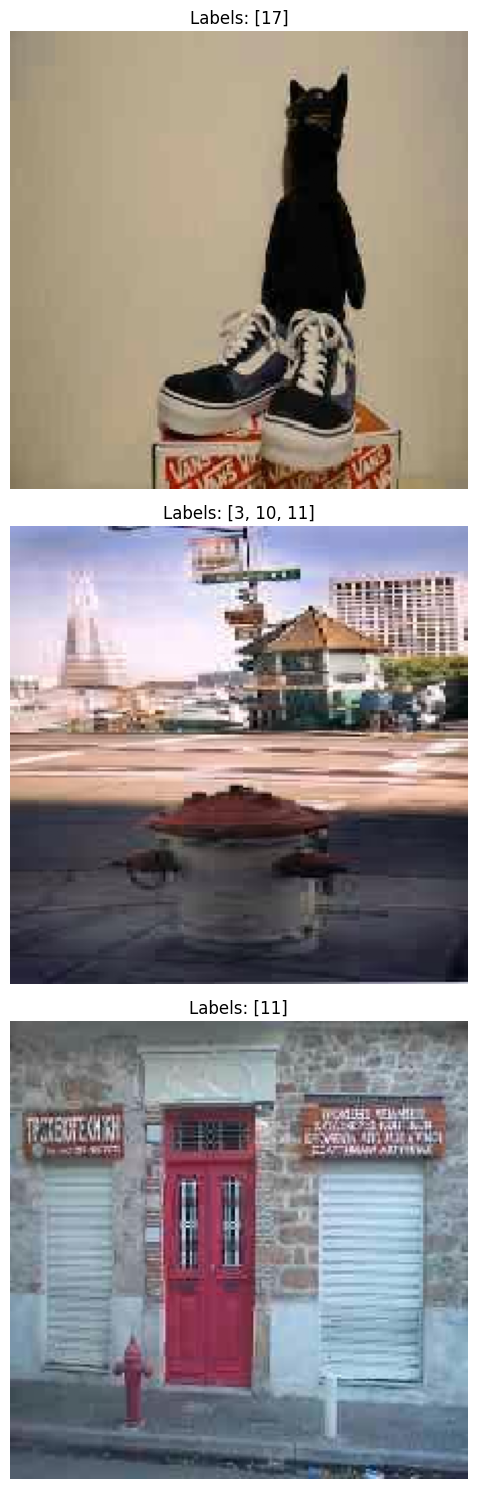

In [10]:


# Créer un MultiLabelBinarizer pour convertir en one-hot encoding
mlb = MultiLabelBinarizer()
train_labels_encoded = mlb.fit_transform(train_df['Labels_list'])
val_labels_encoded = mlb.transform(val_df['Labels_list'])
test_labels_encoded = mlb.transform(test_df['Labels_list'])

# Afficher les classes
print(f"Classes: {mlb.classes_}")
print(f"Nombre de classes: {len(mlb.classes_)}")

# Paramètres pour le prétraitement des images
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

# Fonction pour charger et prétraiter les images
def load_and_preprocess_images(image_ids, img_dir, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    images = []
    for img_id in image_ids:
        # Trouver l'image (peut nécessiter une adaptation si les noms de fichiers diffèrent des IDs)
        img_path = os.path.join(img_dir, img_id)
        # Vérifier si le fichier existe
        if not os.path.exists(img_path):
            # Essayer avec des extensions communes
            for ext in ['.jpg', '.jpeg', '.png']:
                test_path = img_path + ext
                if os.path.exists(test_path):
                    img_path = test_path
                    break
        
        if os.path.exists(img_path):
            # Charger l'image
            img = load_img(img_path, target_size=target_size)
            # Convertir en tableau numpy
            img_array = img_to_array(img)
            # Normaliser les pixels à [0,1]
            img_array = img_array / 255.0
            images.append(img_array)
        else:
            print(f"Image non trouvée: {img_id}")
    
    return np.array(images)

# Charger et prétraiter les images d'entraînement, validation et test
X_train_image = load_and_preprocess_images(train_df['ImageID'], train_img_dir)
X_val_image = load_and_preprocess_images(val_df['ImageID'], val_img_dir)
X_test_image = load_and_preprocess_images(test_df['ImageID'], test_img_dir)

y_train_image = train_labels_encoded
y_val_image = val_labels_encoded
y_test_image = test_labels_encoded

print(f"X_train shape: {X_train_image.shape}")
print(f"y_train shape: {y_train_image.shape}")
print(f"X_val shape: {X_val_image.shape}")
print(f"y_val shape: {y_val_image.shape}")

# Visualiser quelques images avec leurs labels
def show_images_with_labels(images, labels, class_names, num_images=3):
    plt.figure(figsize=(15, 5*num_images))
    for i in range(min(num_images, len(images))):
        plt.subplot(num_images, 1, i+1)
        plt.imshow(images[i])
        
        # Trouver les indices où la valeur est 1 (les classes présentes)
        present_classes = np.where(labels[i] == 1)[0]
        class_names_present = [class_names[idx] for idx in present_classes]
        
        plt.title(f"Labels: {class_names_present}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Afficher quelques images d'entraînement avec leurs labels
show_images_with_labels(X_train_image, y_train_image, mlb.classes_)

In [11]:
num_classes = len(mlb.classes_)
input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

In [12]:

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout


# Fonction pour créer un modèle de transfert d'apprentissage (feature extractor)
def create_transfer_learning_model(base_model_fn, input_shape, num_classes, trainable=False):
    # Charger le modèle pré-entraîné sans la couche fully connected
    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Geler les couches du modèle de base
    base_model.trainable = trainable
    
    # Ajouter une nouvelle tête de classification
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='sigmoid')(x)
    
    # Créer le modèle final
    model = Model(inputs=base_model.input, outputs=predictions)
    
    # Compiler le modèle
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    return model

# Fonction pour le fine-tuning partiel
def create_fine_tuning_model(base_model_fn, input_shape, num_classes, num_layers_to_unfreeze=10):
    # Créer d'abord un modèle avec toutes les couches gelées
    model = create_transfer_learning_model(base_model_fn, input_shape, num_classes, trainable=False)
    
    # Obtenir le modèle de base correctement
    base_model = None
    for layer in model.layers:
        if hasattr(layer, 'layers') and len(layer.layers) > 0:
            base_model = layer
            break
    
    if base_model is None:
        print("Modèle de base non trouvé, utilisation du modèle d'origine")
        # Alternativement, créer directement le modèle de base
        base_model = base_model_fn(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
    
    # Compter le nombre de couches
    total_layers = len(base_model.layers)
    
    # Dégeler les dernières couches spécifiées
    for layer in base_model.layers[total_layers - num_layers_to_unfreeze:]:
        layer.trainable = True
    
    # Recompiler avec un taux d'apprentissage plus faible pour le fine-tuning
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    return model

# Fonction pour créer un modèle from scratch
def create_from_scratch_model(base_model_fn, input_shape, num_classes):
    # Initialiser le modèle avec des poids aléatoires (sans 'imagenet')
    base_model = base_model_fn(
        weights=None,
        include_top=False,
        input_shape=input_shape
    )
    
    # Toutes les couches sont entraînables
    base_model.trainable = True
    
    # Ajouter une nouvelle tête de classification
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='sigmoid')(x)
    
    # Créer le modèle final
    model = Model(inputs=base_model.input, outputs=predictions)
    
    # Compiler le modèle
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    return model



In [13]:
# Définir des callbacks pour améliorer l'entraînement
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6
    )
]

In [14]:
print("Expérimentation 1: Transfert d'apprentissage avec VGG16")
vgg_transfer = create_transfer_learning_model(VGG16, input_shape, num_classes)
histories = vgg_transfer.fit(
    X_train_image, y_train_image,
    batch_size=32,
    epochs=10,
    validation_data=(X_val_image, y_val_image),
    callbacks=callbacks,
    verbose=1
)


Expérimentation 1: Transfert d'apprentissage avec VGG16
Epoch 1/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 97s 234ms/step - accuracy: 0.9018 - loss: 0.2936 - precision: 0.2833 - recall: 0.0429 - val_accuracy: 0.9174 - val_loss: 0.2283 - val_precision: 0.7143 - val_recall: 0.0969 - learning_rate: 0.0010
Epoch 2/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 58s 167ms/step - accuracy: 0.9161 - loss: 0.2328 - precision: 0.6363 - recall: 0.1160 - val_accuracy: 0.9210 - val_loss: 0.2162 - val_precision: 0.7366 - val_recall: 0.1539 - learning_rate: 0.0010
Epoch 3/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 58s 167ms/step - accuracy: 0.9199 - loss: 0.2202 - precision: 0.6795 - recall: 0.1612 - val_accuracy: 0.9215 - val_loss: 0.2112 - val_precision: 0.7679 - val_recall: 0.1505 - learning_rate: 0.0010
Epoch 4/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 58s 167ms/step - accuracy: 0.9221 - loss: 0.2127 - precision: 0.6958 - recall: 0.1885 - val_accuracy: 0.9229 - val_loss: 0.2068 - val_precision: 0.8080 - val_recall: 0.1584 - learning_rate: 0.0

In [15]:
# you can found easily the index from model summary
vgg_transfer.get_layer(index=-4)

<GlobalAveragePooling2D name=global_average_pooling2d, built=True>

In [16]:
# For the image model, extract features from the global average pooling layer
image_feature_extractor = Model(
    inputs=vgg_transfer.input,
    outputs=vgg_transfer.get_layer(index=-4).output
)

In [17]:
image_feature_extractor.save("model/image_model.h5")

<ipython-input-18-ec08045ee38f>:7: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


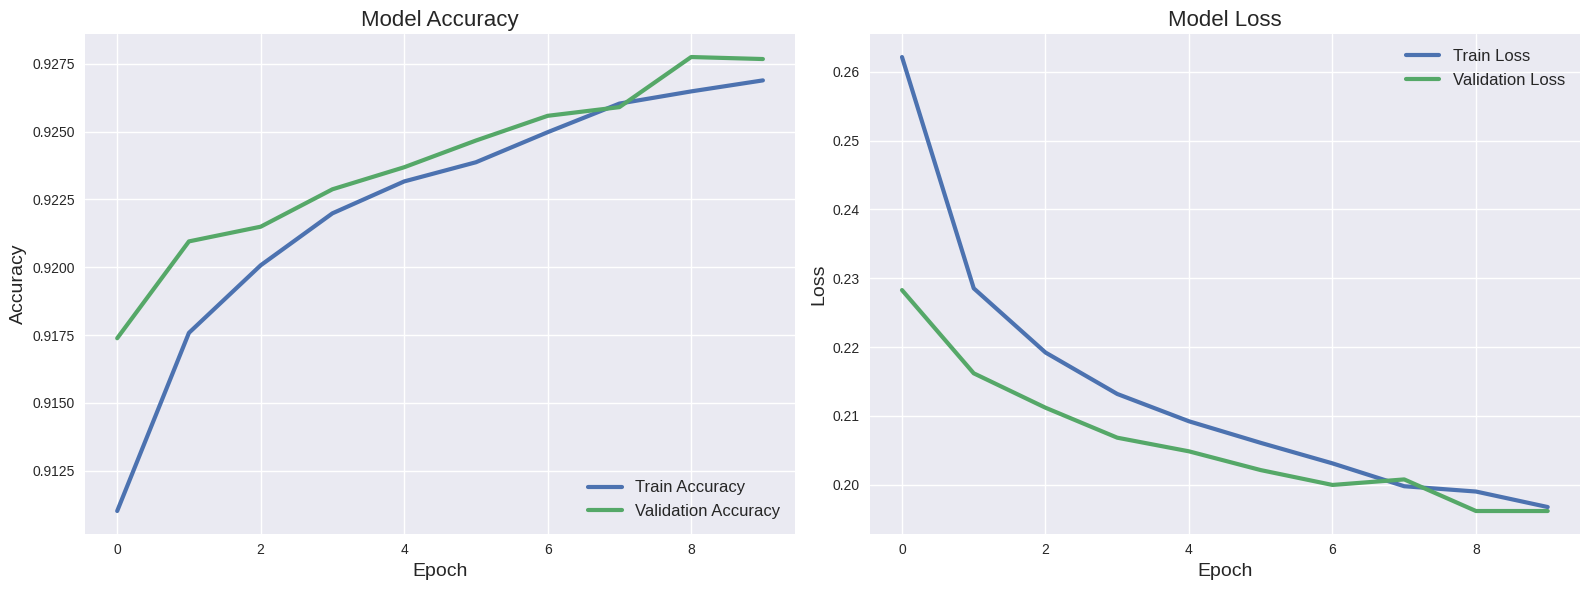

In [18]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """Affiche les courbes d'apprentissage (accuracy et loss) pour l'entraînement et la validation"""
    
    # Configuration du style
    plt.style.use('seaborn')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Graphique Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=3)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=3)
    ax1.set_title('Model Accuracy', fontsize=16)
    ax1.set_ylabel('Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=14)
    ax1.legend(loc='lower right', fontsize=12)
    
    # Graphique Loss
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=3)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=3)
    ax2.set_title('Model Loss', fontsize=16)
    ax2.set_ylabel('Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=14)
    ax2.legend(loc='upper right', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Utilisation avec votre historique d'entraînement
plot_training_history(histories)

In [19]:
plt.savefig('/kaggle/working/training_curves.png', dpi=300, bbox_inches='tight')

<Figure size 800x550 with 0 Axes>

# Text

In [20]:
glove_file = '/kaggle/input/glove/glove.6B.300d.txt'

In [21]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import re

# Pour la lemmatisation (Ex. spaCy en anglais)
import spacy
nlp = spacy.load("en_core_web_sm")  


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
stop_words = set(stopwords.words('english'))  

def clean_text(text):
    # 1) Retirer caractères spéciaux (garde les lettres et chiffres)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', str(text))

    # 2) Tokeniser avec spaCy
    doc = nlp(text.lower())

    # 3) Lemmatiser et retirer les stopwords
    tokens = []
    for token in doc:
        if token.lemma_ not in stop_words and not token.is_space:
            tokens.append(token.lemma_)

    # 4) Join ou retourne la liste
    return " ".join(tokens)


In [23]:
train_text = '/kaggle/input/text-dataset/train_split.csv'
test_text = '/kaggle/input/text-dataset/test_split.csv'
val_text = '/kaggle/input/text-dataset/val_split.csv'

In [24]:
train_df = pd.read_csv(train_text)
test_df = pd.read_csv(test_text)
val_df = pd.read_csv(val_text)


In [25]:

# Fonction pour convertir les labels string en liste de labels
def parse_labels(label_str):
    # Supposons que vos labels sont stockés sous forme de "[3,4]" ou "[5,7]"
    # Nous devons les convertir en liste d'entiers
    if isinstance(label_str, str):
        # Supprimer les crochets et divisez par virgule
        labels = label_str.strip('[]').split(',')
        # Convertir en entiers et retourner sous forme de liste
        return [int(label) for label in labels if label.strip()]
    return []

# Appliquer la fonction de parsing aux colonnes de labels
train_df['Labels_list'] = train_df['Labels_list'].apply(parse_labels)
val_df['Labels_list'] = val_df['Labels_list'].apply(parse_labels)
test_df['Labels_list'] = test_df['Labels_list'].apply(parse_labels)

In [26]:
train_df.head()

,ImageID,Labels,Caption,Labels_list
0,9306.jpg,17,A stuffed animal cat stands in a pair of shoes.,[17]
1,12244.jpg,11 10 3,A fire hydrant is sitting on a street corner.,"[11, 10, 3]"
2,28931.jpg,11,A red fire hydrant is on the curb in front of ...,[11]
3,29430.jpg,8,there is a very old rusted truck that is parke...,[8]
4,11288.jpg,6,The front of a metro bus picking up passengers,[6]


In [27]:
stop_words = set(stopwords.words('english'))  

def clean_text(text):
    # 1) Retirer caractères spéciaux (garde les lettres et chiffres)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', str(text))

    # 2) Tokeniser avec spaCy
    doc = nlp(text.lower())

    # 3) Lemmatiser et retirer les stopwords
    tokens = []
    for token in doc:
        if token.lemma_ not in stop_words and not token.is_space:
            tokens.append(token.lemma_)

    # 4) Join ou retourne la liste
    return " ".join(tokens)


In [28]:
train_df["cleaned_caption"] = train_df["Caption"].apply(clean_text)
val_df["cleaned_caption"] = val_df["Caption"].apply(clean_text)
test_df["cleaned_caption"] = test_df["Caption"].apply(clean_text)

In [29]:
train_df.shape,val_df.shape,test_df.shape

((11146, 5), (2388, 5), (2389, 5))

In [30]:
train_df.head()

,ImageID,Labels,Caption,Labels_list,cleaned_caption
0,9306.jpg,17,A stuffed animal cat stands in a pair of shoes.,[17],stuff animal cat stand pair shoe
1,12244.jpg,11 10 3,A fire hydrant is sitting on a street corner.,"[11, 10, 3]",fire hydrant sit street corner
2,28931.jpg,11,A red fire hydrant is on the curb in front of ...,[11],red fire hydrant curb front building red door
3,29430.jpg,8,there is a very old rusted truck that is parke...,[8],old rust truck park outside
4,11288.jpg,6,The front of a metro bus picking up passengers,[6],front metro bus pick passenger


In [31]:
import gensim.downloader as api

# Ex : 'glove-wiki-gigaword-300' => 300 dimensions
w2v_model = api.load("glove-wiki-gigaword-300")

In [32]:

def text_to_vector(text):
    words = text.split()  # splitted by espace
    vectors = []
    for w in words:
        if w in w2v_model:
            vectors.append(w2v_model[w])
    if len(vectors) == 0:
        return np.zeros(100)  # si aucun mot trouvé
    return np.mean(vectors, axis=0)  # moyenne

train_df["text_vector"] = train_df["cleaned_caption"].apply(text_to_vector)
val_df["text_vector"] = val_df["cleaned_caption"].apply(text_to_vector)
test_df["text_vector"] = test_df["cleaned_caption"].apply(text_to_vector)


In [33]:
train_df.head()

,ImageID,Labels,Caption,Labels_list,cleaned_caption,text_vector
0,9306.jpg,17,A stuffed animal cat stands in a pair of shoes.,[17],stuff animal cat stand pair shoe,"[0.088364005, 0.275418, -0.2952853, -0.193235,..."
1,12244.jpg,11 10 3,A fire hydrant is sitting on a street corner.,"[11, 10, 3]",fire hydrant sit street corner,"[-0.016727999, 0.0026045977, 0.03641052, -0.08..."
2,28931.jpg,11,A red fire hydrant is on the curb in front of ...,[11],red fire hydrant curb front building red door,"[0.1381105, -0.048137132, 0.052144986, -0.3150..."
3,29430.jpg,8,there is a very old rusted truck that is parke...,[8],old rust truck park outside,"[-0.044122003, 0.08170961, -0.3017722, -0.2716..."
4,11288.jpg,6,The front of a metro bus picking up passengers,[6],front metro bus pick passenger,"[0.080298185, -0.047377605, 0.013997996, -0.32..."


In [34]:
# Vérifier la forme des vecteurs
print(train_df["text_vector"].iloc[0].shape)

(300,)


In [35]:
# Transformer le texte en liste d'entiers
train_df["Labels_list"] = train_df["Labels"].apply(lambda x: list(map(int, x.split())))
test_df["Labels_list"] = test_df["Labels"].apply(lambda x: list(map(int, x.split())))
val_df["Labels_list"] = val_df["Labels"].apply(lambda x: list(map(int, x.split())))

In [36]:
# On convertit la colonne "text_vector" (série d'arrays) en un array 2D
X_train = np.vstack(train_df["text_vector"].values)
X_val   = np.vstack(val_df["text_vector"].values)
X_test  = np.vstack(test_df["text_vector"].values)


In [37]:
mlb = MultiLabelBinarizer()
y_train_pad_sequences = mlb.fit_transform(train_df["Labels_list"])
y_val_pad_sequences   = mlb.transform(val_df["Labels_list"])
y_test_pad_sequences  = mlb.transform(test_df["Labels_list"])

In [38]:
max_len = 100                   # Longueur maximale des séquences
max_words = 10000               # Taille du vocabulaire
embedding_dim = 300 
# --- 3. Tokenization et séquençage ---
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['cleaned_caption'])

In [39]:
X_train_ = tokenizer.texts_to_sequences(train_df['cleaned_caption'])
X_val_ = tokenizer.texts_to_sequences(val_df['cleaned_caption'])
X_test_ = tokenizer.texts_to_sequences(test_df['cleaned_caption'])

Je vais utiliser ca, pour les text dans multimodal

In [40]:
X_train_pad_sequences = pad_sequences(X_train_, maxlen=max_len, padding='post', truncating='post')
X_val_pad_sequences = pad_sequences(X_val_, maxlen=max_len, padding='post', truncating='post')
X_test_pad_sequence = pad_sequences(X_test_, maxlen=max_len, padding='post', truncating='post')

In [41]:
# Vérification du nombre de classes
num_classes = y_train_pad_sequences.shape[1]
print(f"Nombre de classes: {num_classes}")

Nombre de classes: 17


In [42]:
word_index = tokenizer.word_index
print(f"Taille du vocabulaire: {len(word_index)}")

Taille du vocabulaire: 3359


In [43]:
# --- 6. Vérification des dimensions ---
print("\nVérification des dimensions:")
print(f"X_train shape: {X_train_pad_sequences.shape}")
print(f"X_val shape: {X_val_pad_sequences.shape}")
print(f"X_test shape: {X_test_pad_sequence.shape}")
print(f"y_train shape: {y_train_pad_sequences.shape}")
print(f"y_val shape: {y_val_pad_sequences.shape}")
print(f"y_test shape: {y_test_pad_sequences.shape}")


Vérification des dimensions:
X_train shape: (11146, 100)
X_val shape: (2388, 100)
X_test shape: (2389, 100)
y_train shape: (11146, 17)
y_val shape: (2388, 17)
y_test shape: (2389, 17)


In [44]:
# --- 7. Exemple d'échantillon ---
print("\nExemple de données transformées:")
print("Texte original:", train_df['Caption'].iloc[0])
print("Texte nettoyé:", train_df['cleaned_caption'].iloc[0])
print("Séquence:", X_train_pad_sequences[0])
print("Labels binarisés:", y_train_pad_sequences[0])


Exemple de données transformées:
Texte original: A stuffed animal cat stands in a pair of shoes.
Texte nettoyé: stuff animal cat stand pair shoe
Séquence: [243 143   8   6 257 312   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
Labels binarisés: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]


In [45]:
# --- Paramètres du modèle ---
max_len = 100                   # Longueur maximale des séquences
max_words = 10000               # Taille du vocabulaire à utiliser
embedding_dim = 300             # Dimensions des embeddings (GloVe 300D)
lstm_units = 128                # Nombre d'unités dans la couche LSTM
num_classes = 17                # Nombre de labels à prédire

# --- Chargement des embeddings GloVe ---
def load_glove_embeddings(glove_file, word_index, embedding_dim=300):
    print(f"Chargement des embeddings GloVe depuis {glove_file}...")
    
    # Dictionnaire pour stocker les embeddings
    embeddings_index = {}
    
    # Ouvrir le fichier GloVe
    with open(glove_file, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            # Convertir les valeurs en array numpy
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    
    print(f"Trouvé {len(embeddings_index)} vecteurs GloVe.")
    
    # Préparer la matrice d'embedding
    # Utiliser exactement max_words pour que la dimension corresponde à celle de la couche Embedding
    embedding_matrix = np.zeros((max_words, embedding_dim))
    
    # Compteurs pour les statistiques
    hits = 0
    misses = 0
    
    # Remplir la matrice avec les embeddings GloVe
    for word, i in word_index.items():
        # Ne pas dépasser max_words
        if i >= max_words:
            continue
            
        # Récupérer le vecteur d'embedding pour ce mot
        embedding_vector = embeddings_index.get(word)
        
        if embedding_vector is not None:
            # Mots trouvés dans GloVe
            embedding_matrix[i] = embedding_vector
            hits += 1
        else:
            # Mots non trouvés dans GloVe (restent à zéro ou peuvent être initialisés aléatoirement)
            misses += 1
    
    print(f"Mots trouvés dans GloVe: {hits}")
    print(f"Mots absents de GloVe: {misses}")
    print(f"Couverture: {hits/(hits+misses)*100:.2f}%")
    
    return embedding_matrix


# Créer la matrice d'embedding
embedding_matrix = load_glove_embeddings(glove_file, word_index, embedding_dim)



Chargement des embeddings GloVe depuis /kaggle/input/glove/glove.6B.300d.txt...
Trouvé 400000 vecteurs GloVe.
Mots trouvés dans GloVe: 3211
Mots absents de GloVe: 148
Couverture: 95.59%


In [46]:
# --- Construction du modèle hybride LSTM-CNN ---

# 1. Input Layer
input_layer = Input(shape=(max_len,), name="Input_Text_Sequence")

# 2. Embedding Layer avec les poids GloVe
embedding_layer = Embedding(
    input_dim=max_words,
    output_dim=embedding_dim,
    input_length=max_len,
    weights=[embedding_matrix],
    trainable=True,
    name="Pretrained_Embedding"
)(input_layer)

# 3. Branche LSTM : Utilise un Bidirectional LSTM pour capturer le contexte dans les deux directions
lstm_branch = Bidirectional(LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2, name="LSTM"))(embedding_layer)
lstm_branch = Dropout(0.3, name="LSTM_Dropout")(lstm_branch)

# 4. Branche CNN 1D : Extraction de motifs locaux dans les séquences
conv_branch = Conv1D(filters=128, kernel_size=3, activation='relu', name="Conv1D_1")(embedding_layer)
conv_branch = BatchNormalization(name="BN_Conv1D_1")(conv_branch)
conv_branch = Dropout(0.3, name="Dropout_Conv1D_1")(conv_branch)
conv_branch = Conv1D(filters=128, kernel_size=3, activation='relu', name="Conv1D_2")(conv_branch)
conv_branch = BatchNormalization(name="BN_Conv1D_2")(conv_branch)
conv_branch = GlobalMaxPooling1D(name="GlobalMaxPool")(conv_branch)

# 5. Concatenation des branches LSTM et CNN
concatenated = Concatenate(name="Concatenate")([lstm_branch, conv_branch])

# 6. Couche Dense intermédiaire
dense_layer = Dense(128, activation='relu', name="Dense_1")(concatenated)
dense_layer = Dropout(0.3, name="Dropout_Dense_1")(dense_layer)

# 7. Couche de sortie avec activation sigmoid pour classification multi-label
output_layer = Dense(num_classes, activation='sigmoid', name="Output")(dense_layer)

# 8. Création et compilation du modèle
model_exp3_am = Model(inputs=input_layer, outputs=output_layer, name="Hybrid_LSTM_CNN_Model")
model_exp3_am.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Construire le modèle avec la forme d'entrée
model_exp3_am.build(input_shape=(None, max_len)) 

# Afficher le résumé du modèle
model_exp3_am.summary()

# --- Entraînement du modèle ---
history3_am = model_exp3_am.fit(
    X_train_pad_sequences, y_train_pad_sequences,
    epochs=15,
    batch_size=32,
    validation_data=(X_val_pad_sequences, y_val_pad_sequences)
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Hybrid_LSTM_CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Input_Text_Sequence       │ (None, 100)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Pretrained_Embedding      │ (None, 100, 300)       │      3,000,000 │ Input_Text_Sequence[0… │
│ (Embedding)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1D_1 (Conv1D)         │ (None, 98, 128)        │        115,328 │ Pretrained_Embedding[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ BN_Conv1D_1               │ (None, 98, 128)        │            512 │ Conv1D_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Dropout_Conv1D_1          │ (None, 98, 128)        │              0 │ BN_Conv1D_1[0][0]      │
│ (Dropout)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1D_2 (Conv1D)         │ (None, 96, 128)        │         49,280 │ Dropout_Conv1D_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 256)            │        439,296 │ Pretrained_Embedding[… │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ BN_Conv1D_2               │ (None, 96, 128)        │            512 │ Conv1D_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ LSTM_Dropout (Dropout)    │ (None, 256)            │              0 │ bidirectional[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ GlobalMaxPool             │ (None, 128)            │              0 │ BN_Conv1D_2[0][0]      │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Concatenate (Concatenate) │ (None, 384)            │              0 │ LSTM_Dropout[0][0],    │
│                           │                        │                │ GlobalMaxPool[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Dense_1 (Dense)           │ (None, 128)            │         49,280 │ Concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Dropout_Dense_1 (Dropout) │ (None, 128)            │              0 │ Dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Output (Dense)            │ (None, 17)             │          2,193 │ Dropout_Dense_1[0][0]  │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 3,656,401 (13.95 MB)

 Trainable params: 3,655,889 (13.95 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 88s 228ms/step - accuracy: 0.2698 - loss: 0.4895 - val_accuracy: 0.6244 - val_loss: 0.1927
Epoch 2/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 80s 229ms/step - accuracy: 0.5903 - loss: 0.1690 - val_accuracy: 0.6466 - val_loss: 0.1361
Epoch 3/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 79s 225ms/step - accuracy: 0.6403 - loss: 0.1465 - val_accuracy: 0.6512 - val_loss: 0.1313
Epoch 4/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 78s 224ms/step - accuracy: 0.6525 - loss: 0.1398 - val_accuracy: 0.6432 - val_loss: 0.1317
Epoch 5/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 80s 229ms/step - accuracy: 0.6743 - loss: 0.1304 - val_accuracy: 0.6549 - val_loss: 0.1327
Epoch 6/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 79s 225ms/step - accuracy: 0.6789 - loss: 0.1257 - val_accuracy: 0.6558 - val_loss: 0.1310
Epoch 7/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 78s 222ms/step - accuracy: 0.6878 - loss: 0.1192 - val_accuracy: 0.6528 - val_loss: 0.1339
Epoch 8/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 81s 231ms/step - accuracy: 0.6900 - loss: 0

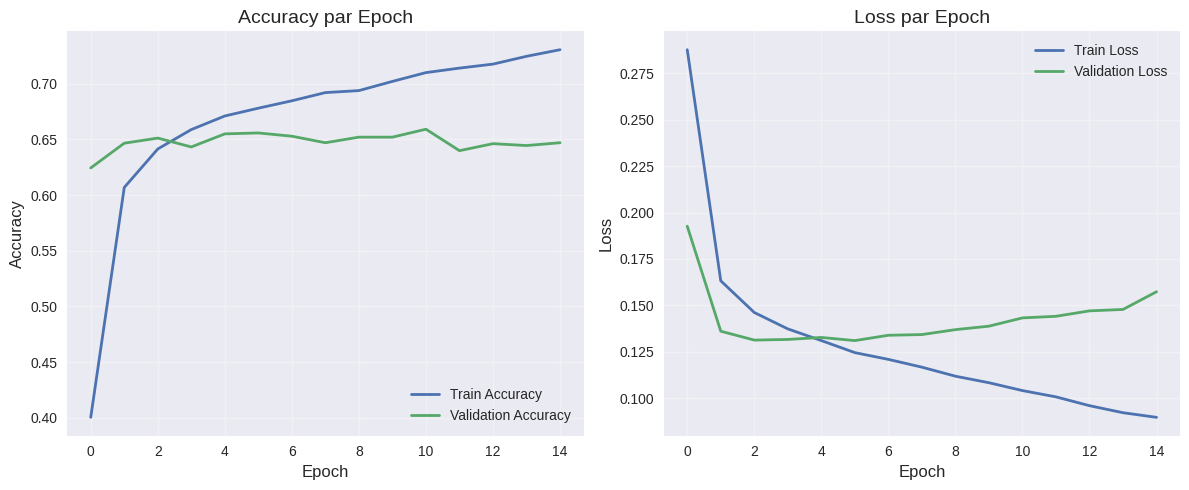

In [47]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def plot_training_history(history):
    """Visualise la performance du modèle pendant l'entraînement"""
    plt.figure(figsize=(12, 5))
    
    # Graphique Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    plt.title('Accuracy par Epoch', fontsize=14)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Graphique Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title('Loss par Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 1. Visualisation de l'entraînement
plot_training_history(history3_am)





In [48]:
plt.savefig('/kaggle/working/training_curves_text.png', dpi=300, bbox_inches='tight')

<Figure size 800x550 with 0 Axes>

In [49]:
# you can found easily the index from model summary
model_exp3_am.get_layer(index=-4)

<Concatenate name=Concatenate, built=True>

In [50]:
# For the text model, extract features from the bi-LSTM layer (replace 4 with the index  of your lstm layer)
text_feature_extractor = Model(
    inputs=model_exp3_am.input,
    outputs=model_exp3_am.get_layer(index=-4).output  # assuming the LSTM output is fourth from last
)

In [51]:
text_feature_extractor.save("model/text_model.h5")

In [52]:
from tensorflow.keras.models import load_model
# Load the models
text_feature_extractor = load_model("/kaggle/working/model/text_model.h5")
image_feature_extractor = load_model("/kaggle/working/model/image_model.h5")

In [53]:
#utiliser les inputs et les outputs
image_features = image_feature_extractor.output
text_features = text_feature_extractor.output

In [54]:
#applatir les caracterisitiques de l'image
image_features_flattend = Flatten()(image_features)

In [55]:
from tensorflow.keras.layers import concatenate
#concatener les caracteristiques
combined_features = concatenate([image_features_flattend, text_features], axis=-1)

In [56]:
#Verification des formes apres la concatenation
print("image_features_flattend : ",image_features_flattend.shape)
print("text_features : ",text_features.shape)
print("combined_features : ",combined_features)

image_features_flattend :  (None, 512)
text_features :  (None, 384)
combined_features :  <KerasTensor shape=(None, 896), dtype=float32, sparse=False, name=keras_tensor_96>


In [57]:
# Ajout des couches denses pour la classification finale
dense_layer = Dense(128, activation='relu')(combined_features) # couche dense avec 128 unités
dropout_layer = Dropout(0.5)(dense_layer) # Ajout d'une couche dropout pour la régularisation
output_layer = Dense(len(mlb.classes_), activation='sigmoid')(dropout_layer) # sortie multilabel

# Création du modèle final
multimodal_model = Model(
    inputs=[image_feature_extractor.input, text_feature_extractor.input], 
    outputs=output_layer
)

# Compilation du modèle (correction de 'acurracy' en 'accuracy')
multimodal_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']  # Correction ici
)

# Afficher le résumé du modèle
multimodal_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1 (Conv2D)     │ (None, 224, 224, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2 (Conv2D)     │ (None, 224, 224, 64)   │         36,928 │ block1_conv1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_pool               │ (None, 112, 112, 64)   │              0 │ block1_conv2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_conv1 (Conv2D)     │ (None, 112, 112, 128)  │         73,856 │ block1_pool[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_conv2 (Conv2D)     │ (None, 112, 112, 128)  │        147,584 │ block2_conv1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_pool               │ (None, 56, 56, 128)    │              0 │ block2_conv2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block3_conv1 (Conv2D)     │ (None, 56, 56, 256)    │        295,168 │ block2_pool[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block3_conv2 (Conv2D)     │ (None, 56, 56, 256)    │        590,080 │ block3_conv1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block3_conv3 (Conv2D)     │ (None, 56, 56, 256)    │        590,080 │ block3_conv2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block3_pool               │ (None, 28, 28, 256)    │              0 │ block3_conv3[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block4_conv1 (Conv2D)     │ (None, 28, 28, 512)    │      1,180,160 │ block3_pool[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block4_conv2 (Conv2D)     │ (None, 28, 28, 512)    │      2,359,808 │ block4_conv1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Input_Text_Sequence       │ (None, 100)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block4_conv3 (Conv2D)     │ (None, 28, 28, 512)    │      2,359,808 │ block4_conv2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Pretrained_Embedding      │ (None, 100, 300)       │      3,000,000 │ Input_Text_Sequence[0… │
│ (Embedding)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block4_pool               │ (None, 14, 14, 512)    │              0 │ block4_conv3[0][0]     │
│ (MaxPooling2D)       

 Total params: 18,436,625 (70.33 MB)

 Trainable params: 3,721,425 (14.20 MB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [58]:
# Callback pour l'early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Entraînement du modèle
history_multimodal = multimodal_model.fit(
    [X_train_image, X_train_pad_sequences],  # Entrées images et textes
    train_labels_encoded,  # étiquettes multilabel
    epochs=10,
    batch_size=64,
    validation_data=([X_val_image, X_val_pad_sequences], val_labels_encoded),
    callbacks=[early_stopping]
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 131s 679ms/step - accuracy: 0.3435 - loss: 0.4008 - val_accuracy: 0.6453 - val_loss: 0.1478
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 124s 707ms/step - accuracy: 0.6830 - loss: 0.1357 - val_accuracy: 0.6503 - val_loss: 0.1381
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 123s 703ms/step - accuracy: 0.7150 - loss: 0.1149 - val_accuracy: 0.6549 - val_loss: 0.1401
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 123s 703ms/step - accuracy: 0.7315 - loss: 0.1043 - val_accuracy: 0.6445 - val_loss: 0.1460
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 123s 700ms/step - accuracy: 0.7345 - loss: 0.0999 - val_accuracy: 0.6583 - val_loss: 0.1478


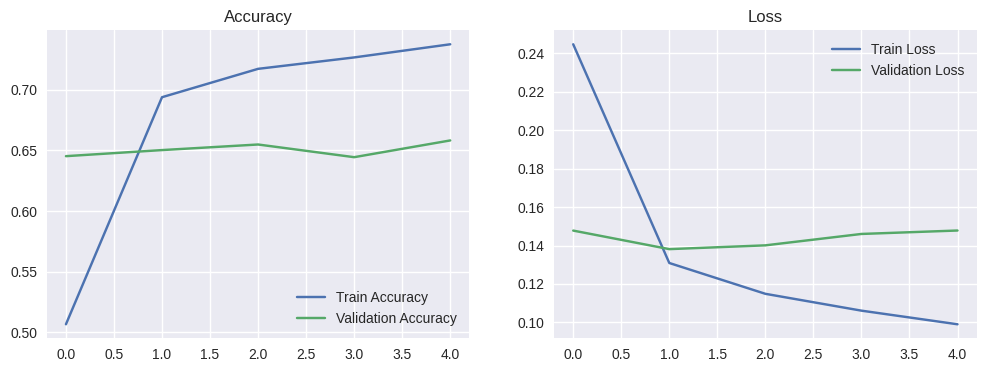

In [59]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    
    plt.show()

plot_training_history(history_multimodal)

In [67]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix
# 1. Faire des prédictions sur l'ensemble de test
y_pred_proba = multimodal_model.predict([X_test_image, X_test_pad_sequence])
y_pred = (y_pred_proba > 0.5).astype(int)  # Seuil à 0.5 pour la classification multi-label







75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 214ms/step


In [76]:
# 2. Évaluation des performances
print("\nRapport de classification complet:\n")
print(classification_report(test_labels_encoded, y_pred, target_names = [str(cls) for cls in mlb.classes_]))


Rapport de classification complet:

              precision    recall  f1-score   support

           2       0.88      0.32      0.47       162
           3       0.65      0.39      0.49       627
           4       0.98      0.67      0.80       207
           5       0.97      0.91      0.94       188
           6       0.94      0.59      0.72       198
           7       0.97      0.88      0.92       192
           8       0.87      0.28      0.42       320
           9       0.90      0.68      0.78       165
          10       0.73      0.35      0.48       206
          11       1.00      0.59      0.74        92
          13       0.91      0.50      0.64        98
          14       1.00      0.54      0.70        28
          15       0.79      0.47      0.59       294
          16       0.90      0.58      0.71       149
          17       0.99      0.92      0.95       215
          18       0.97      0.82      0.88       249
          19       0.98      0.87      0.92 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Performance par classe:
   Classe  Précision    Rappel  F1-score   TP   FP   FN
14     17   0.985075  0.920930  0.951923  198    3   17
3       5   0.971751  0.914894  0.942466  172    5   16
16     19   0.978261  0.865385  0.918367  135    3   21
5       7   0.965517  0.875000  0.918033  168    6   24
15     18   0.966667  0.815261  0.884532  203    7   46
2       4   0.978873  0.671498  0.796562  139    3   68
7       9   0.903226  0.678788  0.775087  112   12   53
9      11   1.000000  0.586957  0.739726   54    0   38
4       6   0.935484  0.585859  0.720497  116    8   82
13     16   0.896907  0.583893  0.707317   87   10   62
11     14   1.000000  0.535714  0.697674   15    0   13
10     13   0.907407  0.500000  0.644737   49    5   49
12     15   0.794286  0.472789  0.592751  139   36  155
1       3   0.648294  0.393939  0.490079  247  134  380
8      10   0.730000  0.354369  0.477124   73   27  133
0       2   0.881356  0.320988  0.470588   52    7  110
6       8   0.872549  0

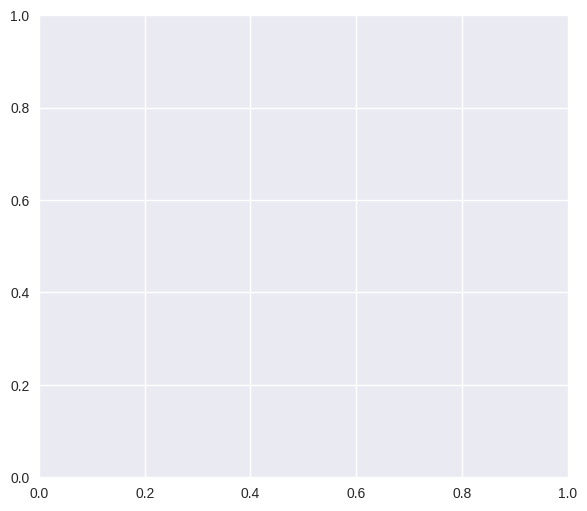

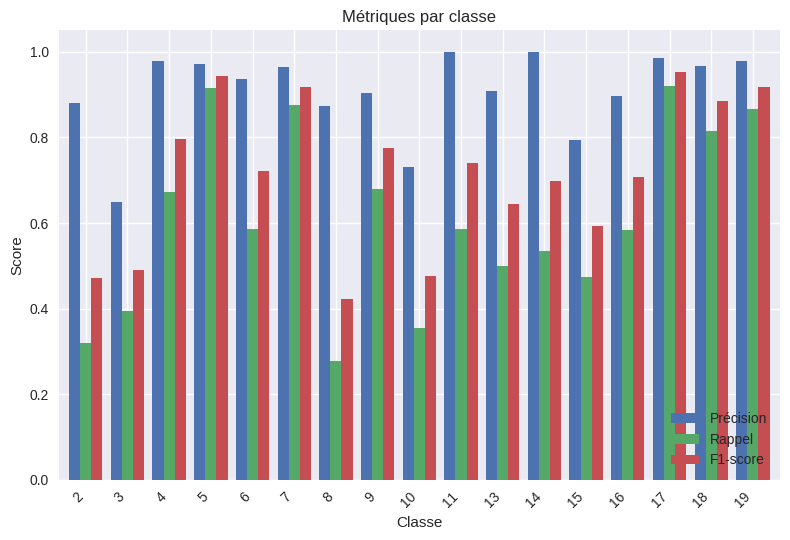

In [78]:

# 3. Analyse par classe
def analyze_class_performance(y_true, y_pred, class_names):
    results = []
    for i, class_name in enumerate(class_names):
        tp = np.sum((y_true[:, i] == 1) & (y_pred[:, i] == 1))
        fp = np.sum((y_true[:, i] == 0) & (y_pred[:, i] == 1))
        fn = np.sum((y_true[:, i] == 1) & (y_pred[:, i] == 0))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        results.append({
            'Classe': class_name,
            'Précision': precision,
            'Rappel': recall,
            'F1-score': f1,
            'TP': tp,
            'FP': fp,
            'FN': fn
        })
    
    return pd.DataFrame(results)

# Création du dataframe d'analyse
performance_df = analyze_class_performance(test_labels_encoded, y_pred, [str(cls) for cls in mlb.classes_])
print("\nPerformance par classe:")
print(performance_df.sort_values(by='F1-score', ascending=False))

# 4. Visualisation des résultats
plt.figure(figsize=(15, 6))

# Graphique des métriques par classe
plt.subplot(1, 2, 1)
performance_df.set_index('Classe')[['Précision', 'Rappel', 'F1-score']].plot.bar(width=0.8)
plt.title('Métriques par classe')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()


mlb.classes_: [ 2  3  4  5  6  7  8  9 10 11 13 14 15 16 17 18 19]
Type des éléments: <class 'numpy.int64'>

Meilleure classe trouvée: 17


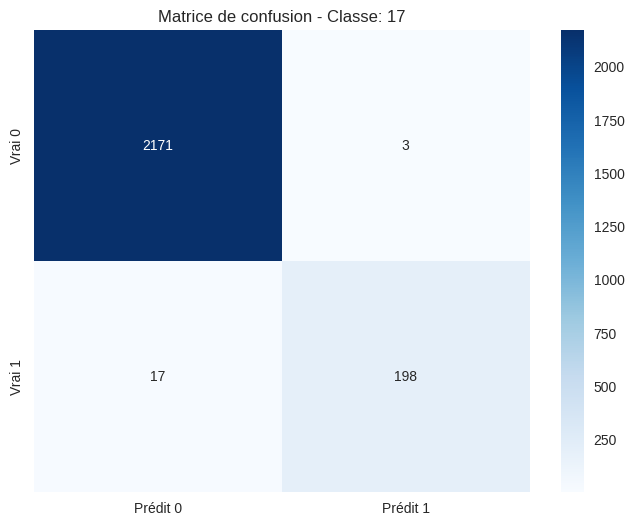

In [82]:
# 1. Afficher pour debug
print("mlb.classes_:", mlb.classes_)
print("Type des éléments:", type(mlb.classes_[0]))

# 2. Trouver la meilleure classe en s'assurant des types compatibles
best_class = str(performance_df.iloc[performance_df['F1-score'].idxmax()]['Classe'])
print("\nMeilleure classe trouvée:", best_class)

# 3. Deux méthodes pour gérer l'indexation
try:
    # Méthode 1: Conversion explicite
    mlb_classes_str = [str(c) for c in mlb.classes_]
    best_class_idx = mlb_classes_str.index(best_class)
    
    # Alternative Méthode 2: Si mlb.classes_ contient déjà des strings
    # best_class_idx = list(mlb.classes_).index(best_class)
    
except ValueError:
    print("\nAttention: Classe non trouvée. Solutions possibles:")
    print("1. Vérifiez que '17' existe bien dans mlb.classes_")
    print("2. Ajustez les types de données (tout en string ou tout en int)")
    print("3. Utilisez une classe par défaut (index 0)")
    
    # Solution de repli
    best_class_idx = 0
    best_class = str(mlb.classes_[best_class_idx])

# 4. Génération de la matrice de confusion
cm = multilabel_confusion_matrix(test_labels_encoded, y_pred)[best_class_idx]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Vrai 0', 'Vrai 1'])
plt.title(f'Matrice de confusion - Classe: {best_class}')
plt.show()

In [83]:
import lime
from lime import lime_image, lime_text
from skimage.segmentation import mark_boundaries

# Initialiser les explainers
explainer_image = lime_image.LimeImageExplainer()
explainer_text = lime_text.LimeTextExplainer(class_names=mlb.classes_)

In [84]:
def multimodal_predict_fn(input_data):
    """
    Fonction de prédiction compatible LIME pour les deux modalités.
    input_data peut être soit une image, soit du texte.
    """
    if isinstance(input_data[0], str):  # Cas texte
        # Prétraitement du texte identique à votre pipeline
        text_vectors = np.array([text_to_vector(text) for text in input_data])
        text_sequences = tokenizer.texts_to_sequences(input_data)
        text_padded = pad_sequences(text_sequences, maxlen=max_len)
        return multimodal_model.predict([np.zeros((len(input_data), *X_train_image.shape[1:])), text_padded])
    else:  # Cas image
        # Prétraitement des images identique à votre pipeline
        processed_imgs = [img/255.0 if img.max() > 1 else img for img in input_data]
        return multimodal_model.predict([np.array(processed_imgs), np.zeros((len(input_data), max_len))])

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

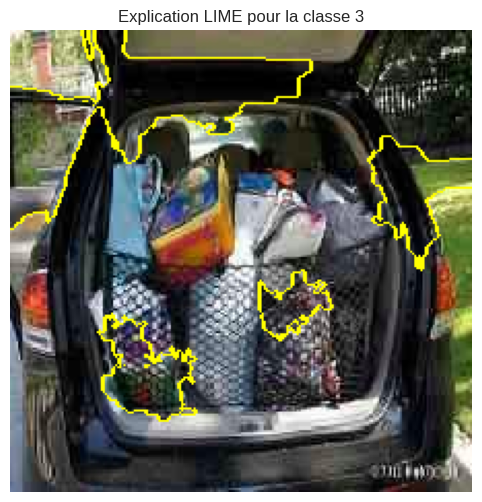

In [85]:
# Sélectionner un exemple
img_idx = 0
image = X_test_image[img_idx]

# Générer l'explication
explanation_img = explainer_image.explain_instance(
    image, 
    multimodal_predict_fn, 
    top_labels=3,
    hide_color=0,
    num_samples=1000
)

# Visualiser
temp, mask = explanation_img.get_image_and_mask(
    explanation_img.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.figure(figsize=(10, 6))
plt.imshow(mark_boundaries(temp/255.0 if temp.max() > 1 else temp, mask))
plt.title(f"Explication LIME pour la classe {mlb.classes_[explanation_img.top_labels[0]]}")
plt.axis('off')
plt.show()

In [87]:
from lime.lime_text import LimeTextExplainer
import numpy as np

# 1. Adapter la fonction de prédiction pour LIME
def text_predict_fn(texts):
    """
    Version corrigée pour gérer les textes de longueurs variables
    """
    # Tokenization et padding
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_len)
    
    # Créer des images factices (car modèle multimodal)
    dummy_images = np.zeros((len(texts), *X_train_image.shape[1:]))
    
    # Prédiction
    return multimodal_model.predict([dummy_images, padded])

# 2. Initialiser l'explainer avec les noms de classes en strings
explainer_text = LimeTextExplainer(
    class_names=[str(cls) for cls in mlb.classes_],
    split_expression=lambda x: x.split(),
    bow=False
)

# 3. Sélectionner un exemple
text_sample = test_df['cleaned_caption'].iloc[0]

# 4. Générer l'explication (avec vérification de taille)
try:
    explanation_text = explainer_text.explain_instance(
        text_sample,
        classifier_fn=text_predict_fn,
        num_features=10,
        num_samples=500,  # Réduire si nécessaire
        top_labels=3
    )
    
    # 5. Visualisation
    explanation_text.show_in_notebook(text=text_sample)
    
except Exception as e:
    print(f"Erreur: {str(e)}")
    print("\nSolutions possibles:")
    print("1. Vérifiez que tokenizer et max_len correspondent à l'entraînement")
    print("2. Réduisez num_samples")
    print("3. Prétraitez le texte exactement comme pendant l'entraînement")

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step


In [1]:
from lime.lime_text import LimeTextExplainer
import numpy as np

class MultimodalExplainer:
    def __init__(self, image_explainer, text_explainer, model, mlb):
        self.image_explainer = image_explainer
        self.text_explainer = text_explainer
        self.model = model
        self.mlb = mlb
        
    def explain(self, image, text, top_labels=3):
        # Explication image
        img_exp = self.image_explainer.explain_instance(
            image,
            lambda x: self.model.predict([x, np.zeros((len(x), max_len))]),
            top_labels=top_labels
        )
        
        # Explication texte
        text_exp = self.text_explainer.explain_instance(
            text,
            lambda x: self.model.predict([np.zeros((len(x), *image.shape)), x]),
            top_labels=top_labels
        )
        
        return img_exp, text_exp

# Initialisation
multimodal_explainer = MultimodalExplainer(explainer_image, explainer_text, multimodal_model, mlb)

# Utilisation
img_exp, text_exp = multimodal_explainer.explain(
    X_test_image[0], 
    test_df['cleaned_caption'].iloc[0]
)

# Visualisation combinée
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Image
temp, mask = img_exp.get_image_and_mask(img_exp.top_labels[0])
ax1.imshow(mark_boundaries(temp/255.0, mask))
ax1.set_title(f"Importance visuelle pour {mlb.classes_[img_exp.top_labels[0]]}")
ax1.axis('off')

# Texte
text_exp.as_pyplot_figure(label=text_exp.top_labels[0])
plt.tight_layout()
plt.show()

NameError: name 'explainer_image' is not defined